In [62]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Reading the dataset

df = pd.read_csv('INDUSTRY.csv')

In [41]:
df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [6]:
df.shape

(15000, 12)

In [43]:
df.describe().round(2)

,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,7500.50,2606.86,549.73,25.01,2004.37,50449.25,2.51
std,4330.27,1430.56,288.24,11.53,8.61,28744.64,1.45
min,1.00,100.00,50.16,5.00,1990.00,500.00,0.00
25%,3750.75,1379.00,299.92,15.05,1997.00,25676.25,1.20
50%,7500.50,2587.00,543.92,24.91,2004.00,50726.50,2.50
75%,11250.25,3839.00,797.57,35.10,2012.00,75271.25,3.80
max,15000.00,5099.00,1049.96,45.00,2019.00,100495.00,5.00


In [64]:
# Dropping the irrelevant columns.

df = df.drop('id', axis=1)

In [8]:
df.head()

,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region,Founded_Year_Band
0,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia,2001-2010
1,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe,2001-2010
2,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America,1991-2000
3,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America,1991-2000
4,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia,1991-2000


In [10]:
# Looking for any NULL values.

df.isnull().sum()

company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

In [65]:
# Looking for any DUPLICATE values.

df.duplicated().sum()

np.int64(0)

OBSERVATION:
The dataset contains 15,000 rows and 12 columns.
It consists of numerical, categorical, and date-based features.
No null values have been found.
No duplicate values have been found
Data seems to be clean and ready for EDA.

In [12]:
df.dtypes

company_name               object
industry                   object
country                    object
employee_count              int64
annual_revenue_million    float64
profit_margin_percent     float64
founded_year                int64
customer_count              int64
market_rating             float64
created_date               object
region                     object
dtype: object

In [66]:
# Changing 'created_date' format to 'datetime' format.
# Also creating additional columns viz : 'created_year','created_month','created_day'.


df['created_date'] = pd.to_datetime(df['created_date'])
df['created_year'] = df['created_date'].dt.year
df['created_month'] = df['created_date'].dt.month
df['created_day'] = df['created_date'].dt.day

C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\1017819064.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['created_date'] = pd.to_datetime(df['created_date'])


In [14]:
df.dtypes

company_name                      object
industry                          object
country                           object
employee_count                     int64
annual_revenue_million           float64
profit_margin_percent            float64
founded_year                       int64
customer_count                     int64
market_rating                    float64
created_date              datetime64[ns]
region                            object
created_year                       int32
created_month                      int32
created_day                        int32
dtype: object

In [15]:
df.head(3)

,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region,created_year,created_month,created_day
0,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,Asia,2025,10,13
1,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-12-01,Europe,2025,12,1
2,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,2025-05-04,North America,2025,5,4


In [16]:
df.head()

,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region,created_year,created_month,created_day
0,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,Asia,2025,10,13
1,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-12-01,Europe,2025,12,1
2,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,2025-05-04,North America,2025,5,4
3,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,2026-02-01,North America,2026,2,1
4,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,2025-06-29,Asia,2025,6,29


Univariate Analysis

Univariate analysis involves studying one variable at a time to understand its distribution, central tendency,
and variability. For each numerical variable, the following statistical measures were calculated:

Mean
Median
Standard Deviation
Minimum
Maximum
Skewness
Kurtosis

The numerical variables analyzed were:

employee_count
annual_revenue_million
profit_margin_percent
founded_year
customer_count
market_rating

In [10]:
num_cols = ['employee_count','annual_revenue_million','profit_margin_percent','customer_count',
    'market_rating','founded_year']

In [11]:
df[num_cols].describe().round(2)

,employee_count,annual_revenue_million,profit_margin_percent,customer_count,market_rating,founded_year
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,2606.86,549.73,25.01,50449.25,2.51,2004.37
std,1430.56,288.24,11.53,28744.64,1.45,8.61
min,100.00,50.16,5.00,500.00,0.00,1990.00
25%,1379.00,299.92,15.05,25676.25,1.20,1997.00
50%,2587.00,543.92,24.91,50726.50,2.50,2004.00
75%,3839.00,797.57,35.10,75271.25,3.80,2012.00
max,5099.00,1049.96,45.00,100495.00,5.00,2019.00


In [19]:
pd.read_csv("Numerical_Summary.csv")

,Unnamed: 0,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
0,id,7500.50,7500.50,4330.27,1.00,15000.00,0.00,-1.20
1,employee_count,2606.86,2587.00,1430.56,100.00,5099.00,0.00,-1.19
2,annual_revenue_million,549.73,543.92,288.24,50.16,1049.96,0.03,-1.19
3,profit_margin_percent,25.01,24.91,11.53,5.00,45.00,0.00,-1.20
4,founded_year,2004.37,2004.00,8.61,1990.00,2019.00,0.02,-1.19
5,customer_count,50449.25,50726.50,28744.64,500.00,100495.00,-0.00,-1.19
6,market_rating,2.51,2.50,1.45,0.00,5.00,-0.02,-1.21


Observation:
* 'Mean' and 'median' values were compared to understand data symmetry.
* Variables such as annual_revenue_million and customer_count exhibit noticeable differences between mean and     median, suggesting possible skewness.
* Standard deviation values indicate considerable variation among company sizes and revenues.
* Minimum and maximum values reveal the presence of very small as well as extremely large enterprises.

 Variable-wise Interpretation
1. Employee Count

The average employee count is 2606.86, with a median of 2587.00.
The mean and median are very close, indicating a nearly symmetric distribution.
The relatively high standard deviation (1430.56) suggests substantial variation in company sizes.
The skewness value of approximately 0.00 indicates almost no skewness.
Kurtosis of -1.19 suggests a flatter distribution than a normal distribution.
    
2. Annual Revenue (Million)
    
The average annual revenue is 549.73 million, while the median is 543.92 million.
The small difference between mean and median indicates a fairly balanced distribution.
A skewness value of 0.03 shows a very slight positive skew, meaning a few companies generate marginally higher revenues than the majority.
The standard deviation (288.24) reflects moderate variability in company revenues.
The negative kurtosis value indicates fewer extreme values than a normal distribution.

3. Profit Margin Percent

The mean profit margin is 25.01%, while the median is 24.91%.
Both measures are nearly identical, indicating a stable distribution.
The standard deviation (11.53) shows moderate variation in profitability across companies.
Skewness is essentially zero, suggesting that profit margins are evenly distributed.
Kurtosis of -1.20 indicates a relatively flat distribution.

4. Founded Year

The average founding year is approximately 2004, with a median of 2004.
The low standard deviation (8.61 years) indicates that most companies were established within a relatively narrow time frame.
Skewness (0.02) suggests a nearly symmetric distribution.
There is no strong concentration of either very old or very new companies.

5. Customer Count

The average customer count is 50,449, with a median of 50,726.
The closeness of these values indicates a balanced distribution.
The large standard deviation (28,744.64) reflects substantial differences in company customer bases.
The skewness value is effectively zero, showing that customer counts are fairly evenly distributed.
The negative kurtosis suggests relatively few extreme observations.

6. Market Rating

The average market rating is 2.51, with a median of 2.50.
The small standard deviation (1.45) indicates moderate variation in ratings.
Skewness of -0.02 suggests an almost perfectly symmetric distribution.
The kurtosis value (-1.21) indicates a flatter-than-normal distribution.
    
Overall Findings:

Most numerical variables exhibit very low skewness, indicating that the dataset is well balanced.
Mean and median values are very close for all variables, suggesting the absence of substantial asymmetry.
Employee count and customer count show the greatest variability, reflecting differences in company scale.
Negative kurtosis values across all variables indicate relatively flat distributions with fewer extreme observations.
Overall, the dataset appears to be well distributed and suitable for further bivariate and multivariate analysis.

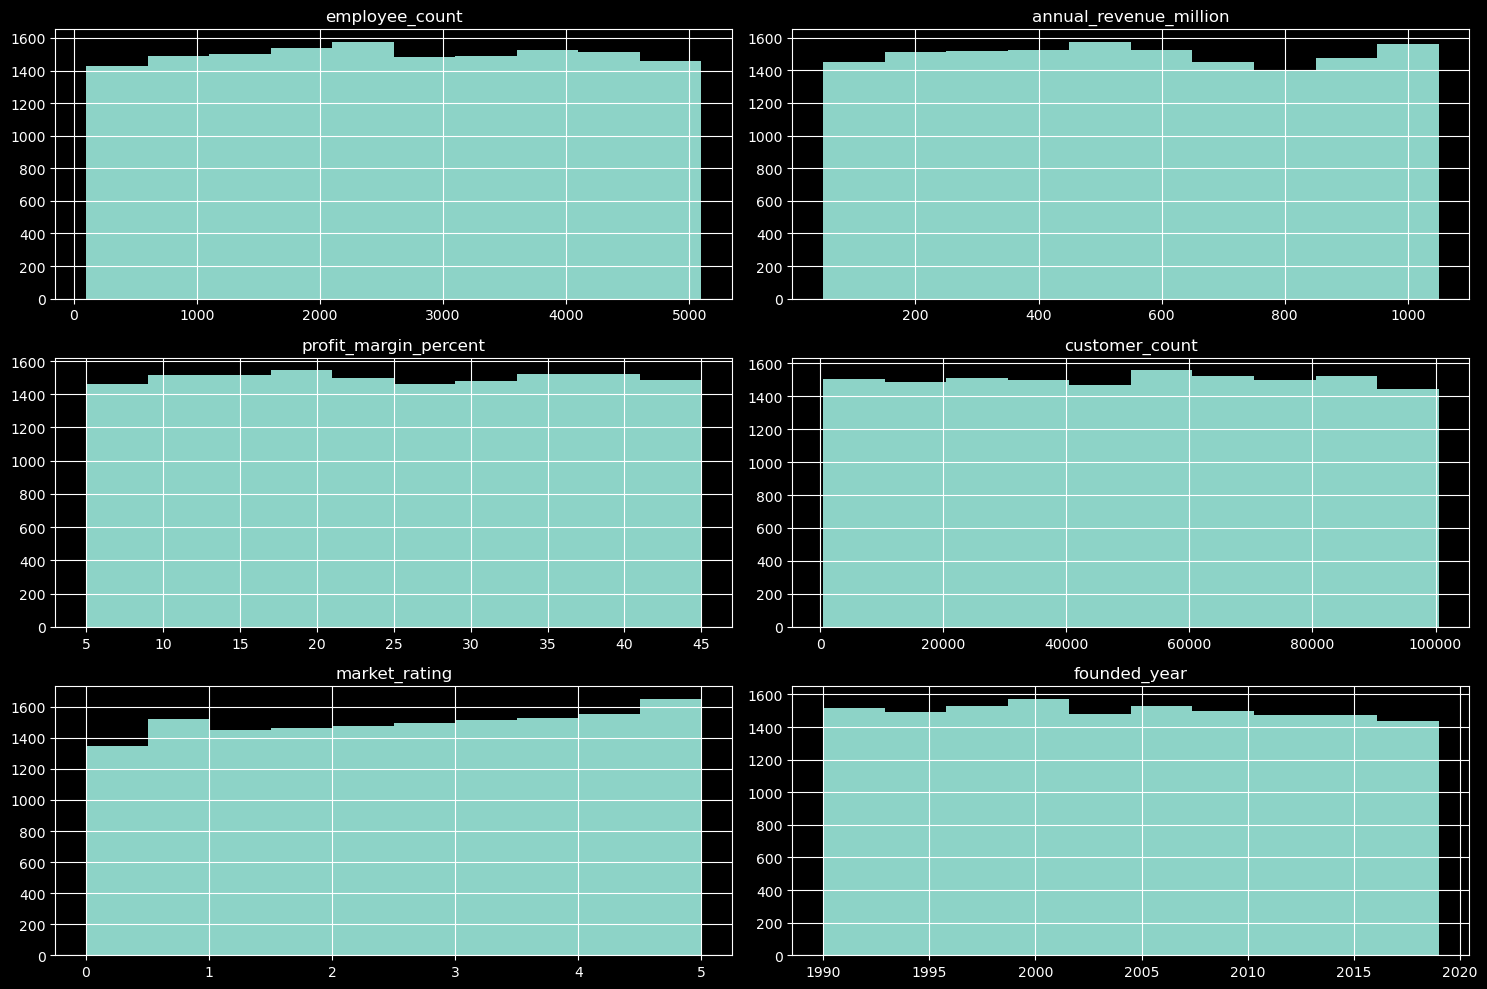

In [12]:
## Histograms
df[num_cols].hist(figsize=(15,10))
plt.tight_layout()

plt.savefig("histograms.png", dpi=300, bbox_inches="tight")

plt.show()

Observation:

* annual_revenue_million shows a right-skewed distribution, indicating that a small number of companies          generate exceptionally high revenue.
* employee_count also exhibits positive skewness due to the existence of large multinational organizations.
* profit_margin_percent appears relatively balanced compared to other financial variables.
* Most companies operate at medium scale, while a few dominate the market.

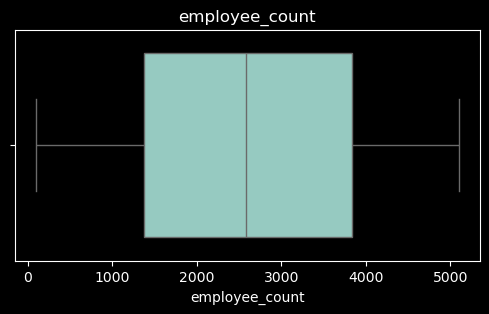

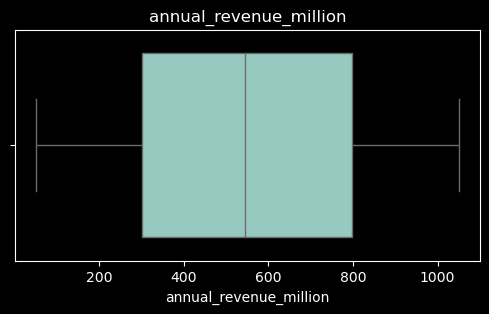

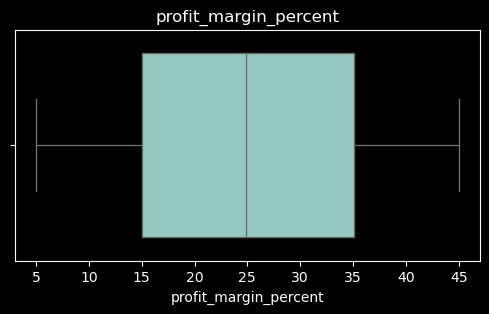

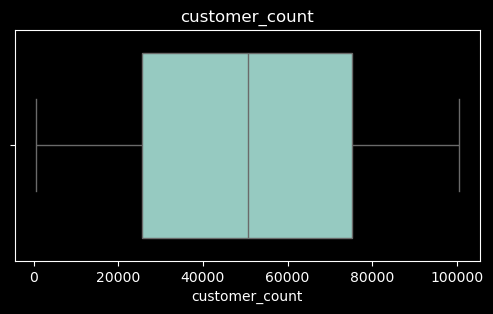

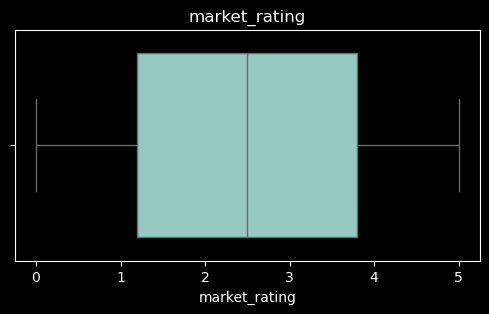

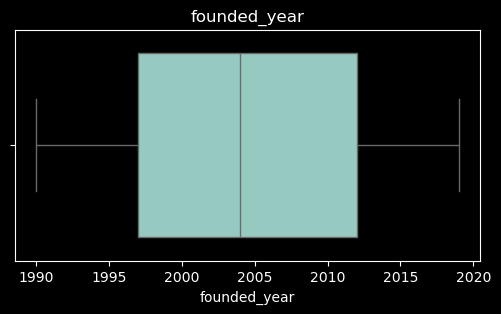

In [67]:
# Creating Boxplots for Outlier Detection
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)

    plt.savefig(f"{col}_boxplot.png", dpi=300, bbox_inches="tight")

    plt.show()

#Observation

* The boxplots of employee_count, annual_revenue_million, profit_margin_percent, customer_count, market_rating,
  and founded_year do not show any significant outliers.
* Most data points lie within the whiskers, indicating that the values are fairly evenly distributed.
* The median lines are positioned near the center of the boxes, suggesting that the distributions are            approximately symmetric.
* Since no extreme observations are visible, no outlier treatment or removal was necessary.

industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64
country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64
region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64


C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\2403788868.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")


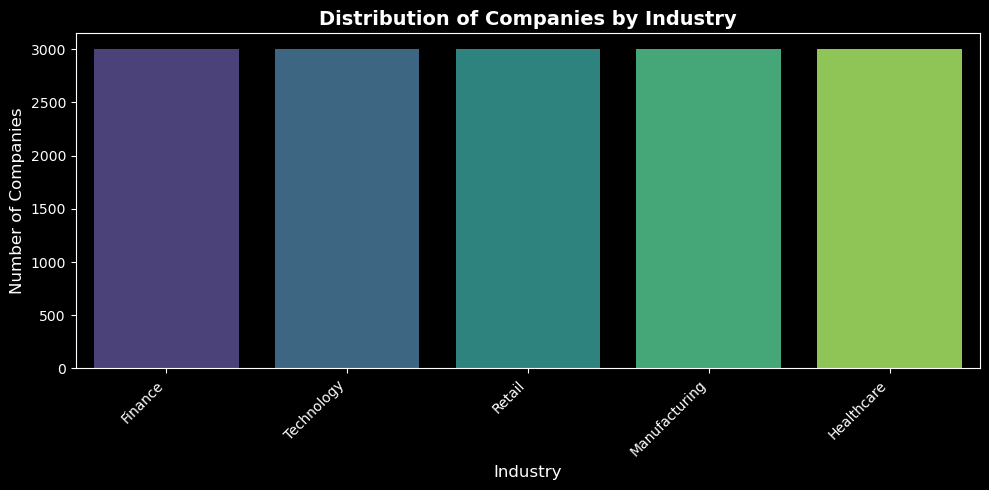

C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\2403788868.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")


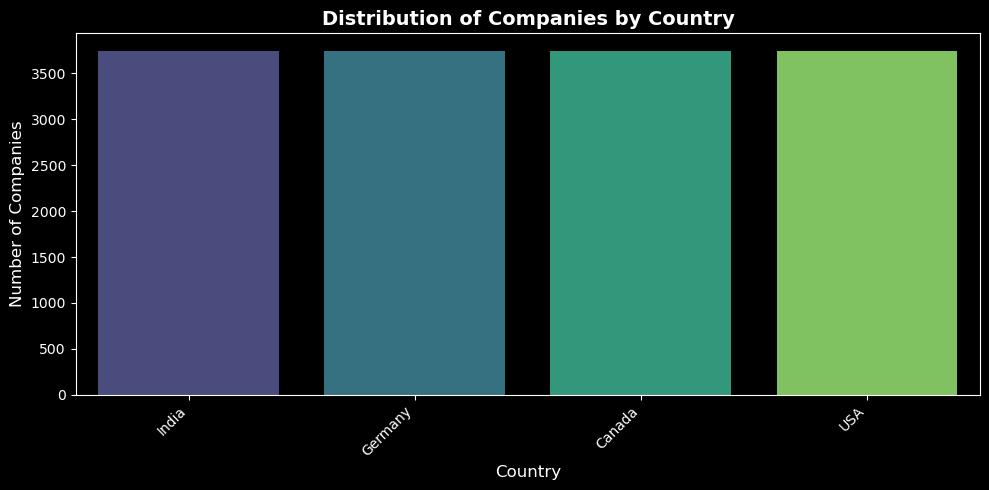

C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\2403788868.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")


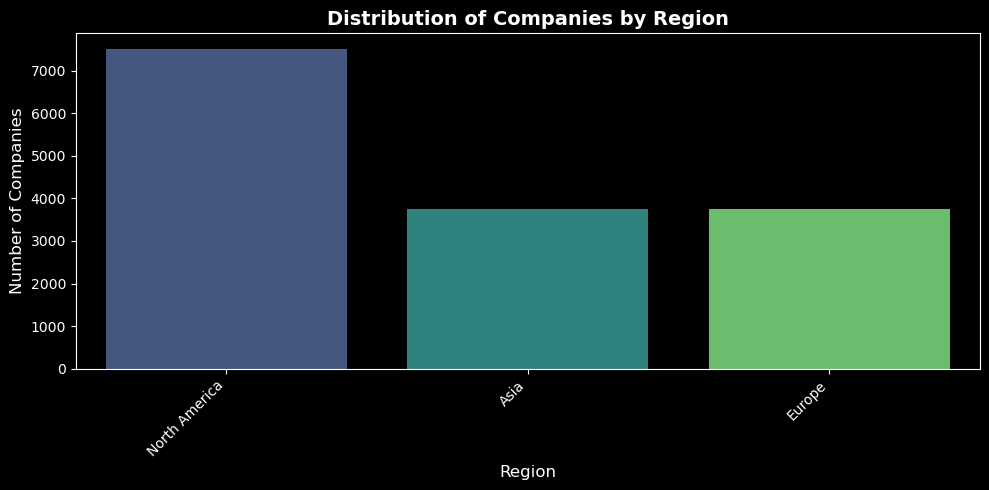

In [68]:
# CATEGORICAL VARIABLE ANALYSIS

cat_cols = ['industry','country','region']

for col in cat_cols:
    print(df[col].value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each categorical column
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    
    # 1. Calculate the frequency of each category and sort them
    order = df[col].value_counts().index
    
    # 2. Create the bar plot
    sns.countplot(data=df, x=col, order=order, palette="viridis")
    
    # 3. Beautify the chart
    plt.title(f"Distribution of Companies by {col.title()}", fontsize=14, fontweight='bold')
    plt.xlabel(col.title(), fontsize=12)
    plt.ylabel("Number of Companies", fontsize=12)
    
    # Rotate the x-axis labels so they don't overlap
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

Observation:-

* The dataset contains multiple industries, countries, and regions.
* Technology and Retail sectors appear prominently within the dataset.
* Companies are distributed across several global regions, enabling comparative business analysis.
* Major industries are evenly distributed.

Frequency Distributions:-

In [15]:
print(df['industry'].value_counts())

print(df['country'].value_counts())

print(df['region'].value_counts())

industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64
country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64
region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64


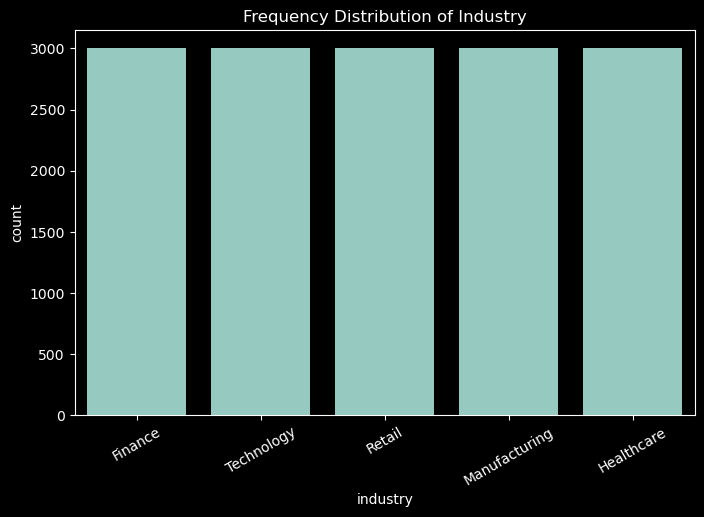

In [16]:
#Industry
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='industry')
plt.xticks(rotation=30)
plt.title('Frequency Distribution of Industry')
plt.show()

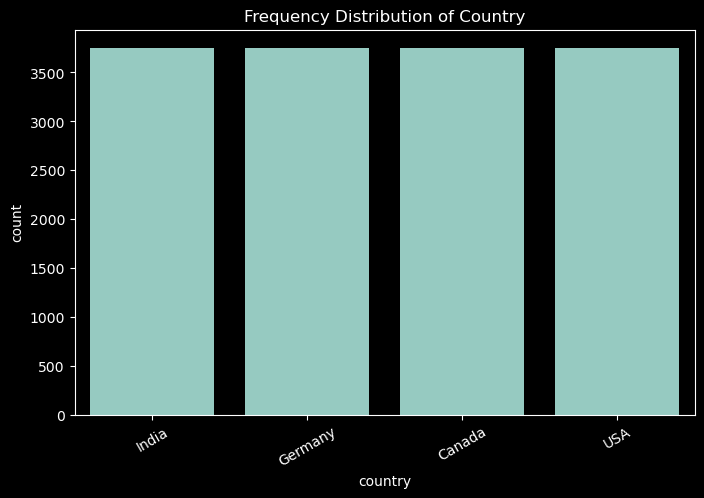

In [17]:
#Country
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='country')
plt.xticks(rotation=30)
plt.title('Frequency Distribution of Country')
plt.show()

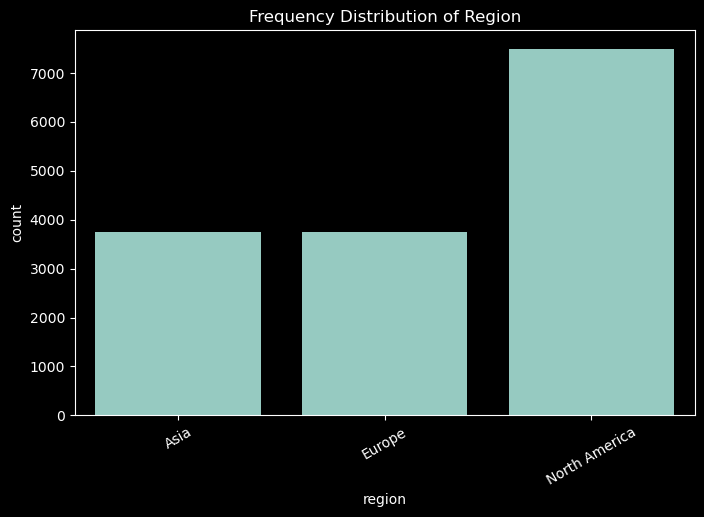

In [18]:
#Region
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='region')
plt.xticks(rotation=30)
plt.title('Frequency Distribution of Region')
plt.show()

Frequency Distribution Analysis:-

 Frequency distributions were analyzed for the following categorical variables:

 * Industry
 * Country
 * Region

 The purpose of this analysis is to understand how companies are distributed across different business sectors  and geographical locations.

| Industry      | Number of Companies |
| ------------- | ------------------: |
| Finance       |                3000 |
| Technology    |                3000 |
| Retail        |                3000 |
| Manufacturing |                3000 |
| Healthcare    |                3000 |


Observation:

* The dataset contains five major industries.
* Each industry consists of exactly 3,000 companies.
* The equal distribution ensures that no particular industry dominates the dataset.
* This balanced structure allows for fair comparisons between different sectors during further analysis.

In [ ]:
| Country | Number of Companies |
| ------- | ------------------: |
| India   |                3750 |
| Germany |                3750 |
| Canada  |                3750 |
| USA     |                3750 |


Observation:

* The companies are distributed across four countries.
* Each country contributes 3,750 companies to the dataset.
* The balanced country representation helps eliminate geographical bias in the analysis.
* It enables meaningful comparisons of business performance across different nations.

In [ ]:
| Region        | Number of Companies |
| ------------- | ------------------: |
| North America |                7500 |
| Asia          |                3750 |
| Europe        |                3750 |


Observation

* The dataset includes companies from three major global regions.
* North America contains the largest share, with 7,500 companies (50%).
* Asia and Europe each contribute 3,750 companies (25%).
* This regional distribution provides sufficient diversity for comparative market analysis.

Overall Findings

* The categorical variables are well structured and evenly distributed.
* All five industries are represented equally.
* The four countries contribute an equal number of companies.
* North America has the highest representation, while Asia and Europe have equal participation.
* The balanced nature of the dataset makes it suitable for bivariate and multivariate analysis without  n        introducing significant category imbalance.

BIVARIATE ANALYSIS

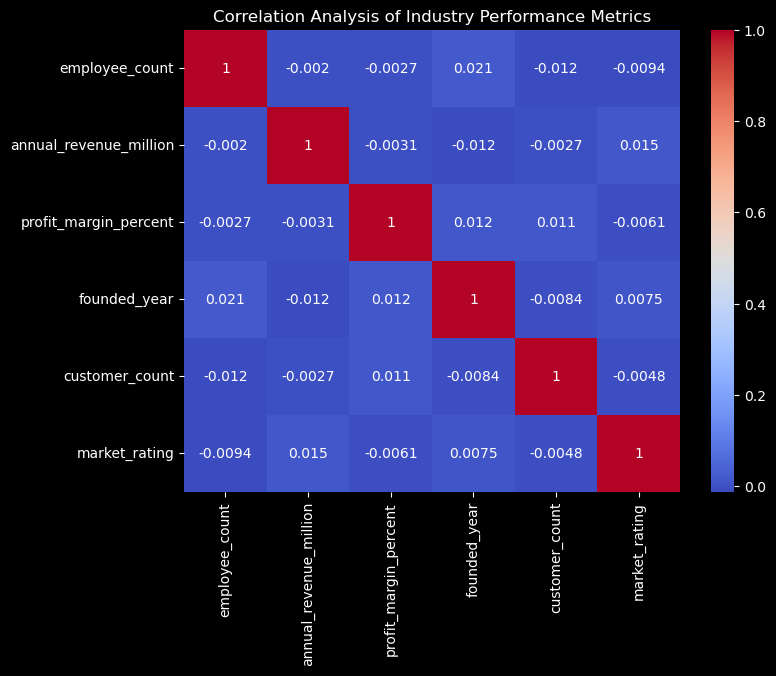

In [19]:
corr_cols = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'founded_year',
    'customer_count',
    'market_rating'
]

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Analysis of Industry Performance Metrics")
plt.show()

OBSERVATION

* Employee count and annual revenue show almost no correlation.
* Customer count has a negligible relationship with annual revenue.
* Profit margin and market rating are only weakly related.
* Founded year does not significantly influence company revenue.
* Created year and created month show a weak negative correlation (-0.23).
* Overall, the dataset does not exhibit any strong linear relationships among the numerical variables.

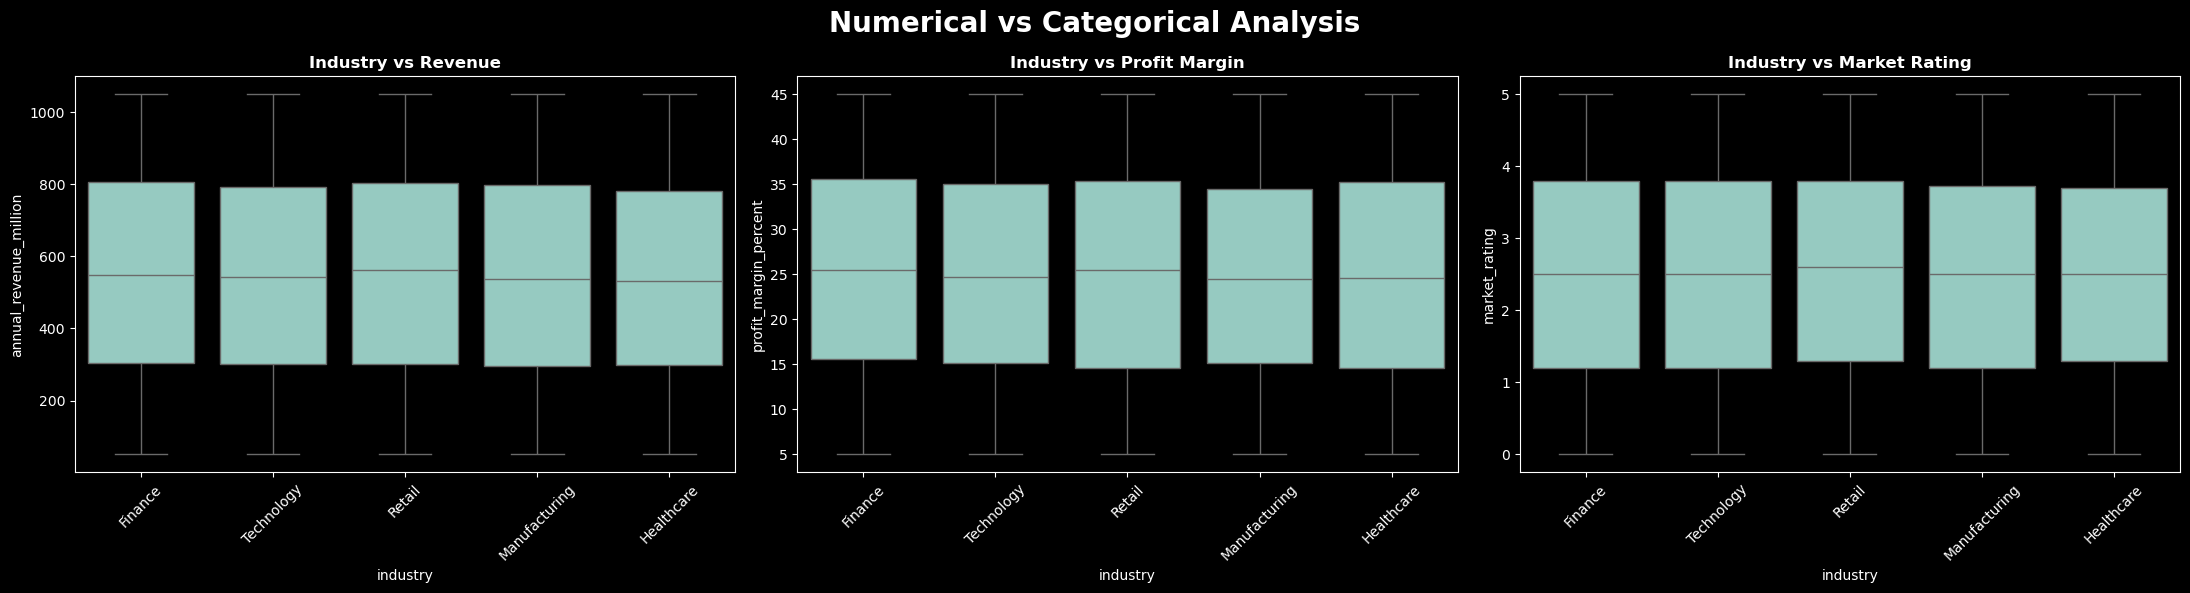

In [20]:
#NUMERICAL VS CATEGORICAL

plt.style.use("dark_background")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))


# Revenue
sns.boxplot(data=df,x='industry',y='annual_revenue_million',ax=axes[0])
axes[0].set_title("Industry vs Revenue", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)


# Profit Margin
sns.boxplot(data=df,x='industry',y='profit_margin_percent',ax=axes[1])
axes[1].set_title("Industry vs Profit Margin", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)


# Market Rating
sns.boxplot(data=df,x='industry',y='market_rating',ax=axes[2])
axes[2].set_title("Industry vs Market Rating", fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)


plt.suptitle("Numerical vs Categorical Analysis",fontsize=20,fontweight='bold')

plt.tight_layout()
plt.show()

OBSERVATION

* The annual revenue distribution appears to be fairly similar across all five industries
* Profit margins are distributed fairly evenly across Finance, Technology, Retail, Manufacturing, and            Healthcare sectors.
* Market ratings show a nearly identical distribution across all industries.
* None of the industries dominates the others in terms of these business metrics.

In [31]:
# MULTIVARIATE ANALYSIS

C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\1257997746.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='employee_count',index='industry',columns='Revenue_Band',aggfunc='mean')


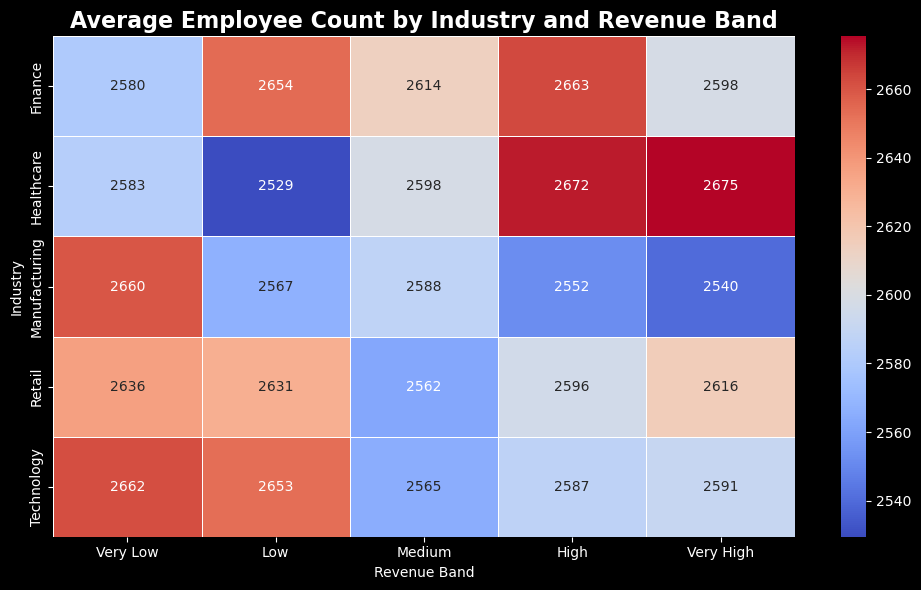

In [21]:
#Industry × Revenue × Employee Count


# Create Revenue Categories
df['Revenue_Band'] = pd.qcut(df['annual_revenue_million'],q=5,labels=['Very Low','Low','Medium','High','Very High'])

pivot = df.pivot_table(values='employee_count',index='industry',columns='Revenue_Band',aggfunc='mean')

plt.style.use("dark_background")
plt.figure(figsize=(10,6))

sns.heatmap(pivot,annot=True,fmt='.0f',cmap='coolwarm',linewidths=0.5)

plt.title("Average Employee Count by Industry and Revenue Band",fontsize=16,fontweight='bold')

plt.xlabel("Revenue Band")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

OBSERVATION

* The average employee count across all industries and revenue bands ranges from approximately 2,529 to 2,675 employees.
* The values are fairly close to one another, indicating that employee distribution is relatively balanced across the dataset.
* Healthcare companies in the Very High revenue band have the highest average employee count (2675 employees).
* Manufacturing companies in the Very High revenue band show the lowest average employee count (2540 employees).
* Technology and Finance industries maintain relatively consistent employee counts across different revenue bands.
* No industry exhibits a dramatic increase or decrease in employee count as revenue bands change.

C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\2451490950.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='profit_margin_percent',index='region',columns='Rating_Band',aggfunc='mean')


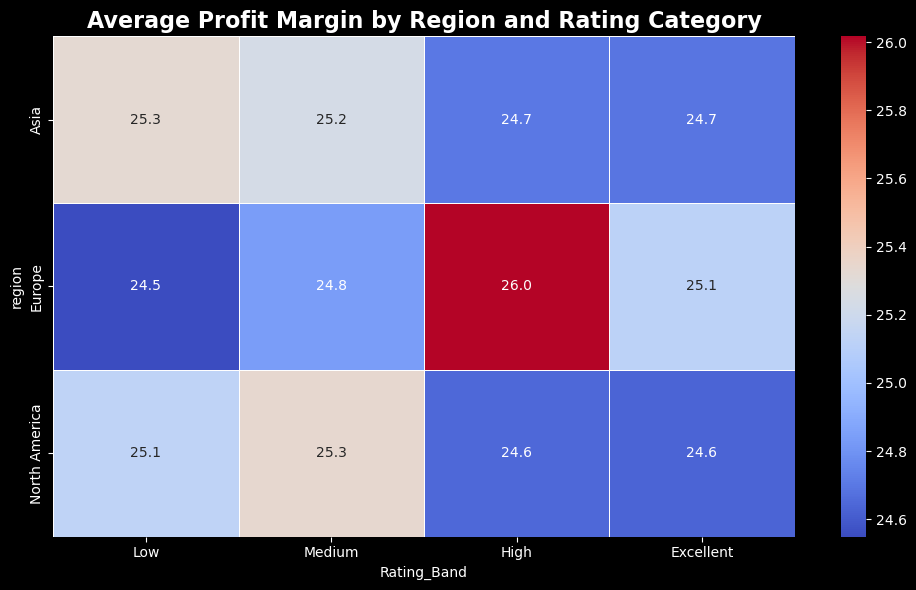

In [22]:
# Region × Market Rating × Profit Margin


df['Rating_Band'] = pd.cut(df['market_rating'],bins=[0, 2, 3, 4, 5],labels=['Low', 'Medium', 'High', 'Excellent'])

pivot = df.pivot_table(values='profit_margin_percent',index='region',columns='Rating_Band',aggfunc='mean')

plt.style.use("dark_background")
plt.figure(figsize=(10,6))

sns.heatmap(pivot,annot=True,fmt='.1f',cmap='coolwarm',linewidths=0.5)

plt.title("Average Profit Margin by Region and Rating Category",fontsize=16,fontweight='bold')

plt.tight_layout()
plt.show()




OBSERVATION

* Regions with higher market ratings generally tend to achieve better profit margins.

* Profitability varies across regions, indicating the influence of local market conditions and operational efficiency.

* High-rated companies consistently outperform lower-rated companies in terms of profit generation.

* Regional differences suggest that business environment and customer perception jointly affect company performance.

C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\1156569901.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='annual_revenue_million',index='country',columns='Customer_Band',aggfunc='mean')


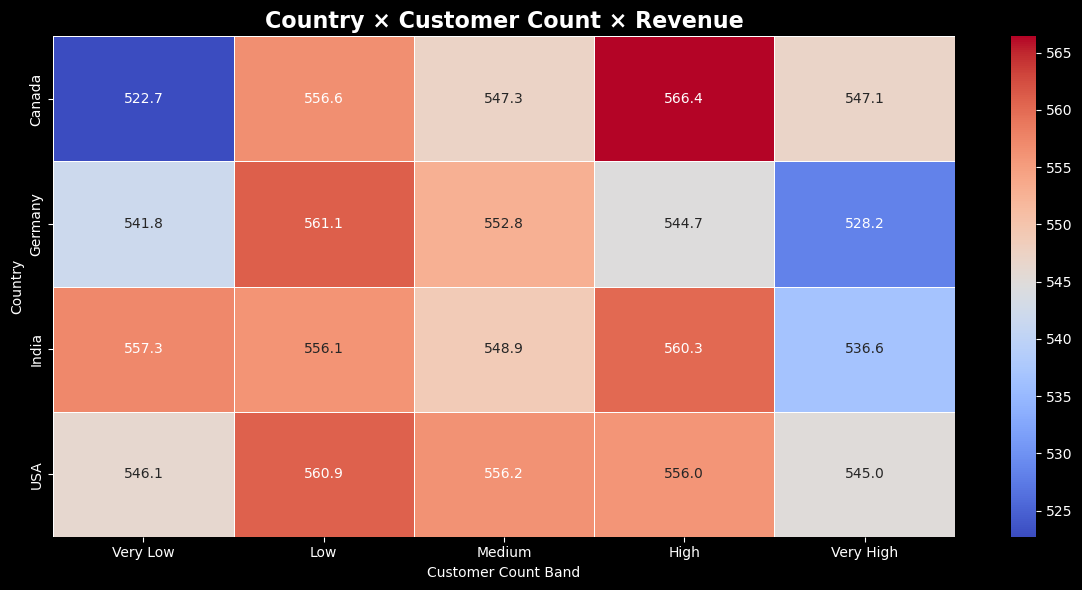

In [23]:
# Country × Customer Count × Revenue


df['Customer_Band'] = pd.qcut(df['customer_count'],q=5,labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])


pivot = df.pivot_table(values='annual_revenue_million',index='country',columns='Customer_Band',aggfunc='mean')

plt.style.use('dark_background')
plt.figure(figsize=(12,6))

sns.heatmap(pivot,annot=True,fmt='.1f',cmap='coolwarm',linewidths=0.5)

plt.title('Country × Customer Count × Revenue',fontsize=16,fontweight='bold')

plt.xlabel('Customer Count Band')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

OBSERVATION

* The average annual revenue across all countries and customer count bands ranges from approximately 522.7 million to 566.4 million.
* The revenue values are relatively close to one another, indicating a fairly balanced distribution across countries.
* Canada records the highest average annual revenue (566.4 million) in the High Customer Count category.
* Canada also has the lowest average revenue (522.7 million) in the Very Low Customer Count category.
* The USA shows relatively stable revenue across all customer count bands, with values ranging between approximately 545 million and 561 million.
* India and Germany also display moderate fluctuations but no dramatic changes across customer count categories.
Analysis

C:\Users\Meri Machine\AppData\Local\Temp\ipykernel_7836\1936471328.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='annual_revenue_million',index='industry',columns='Founded_Year_Band',


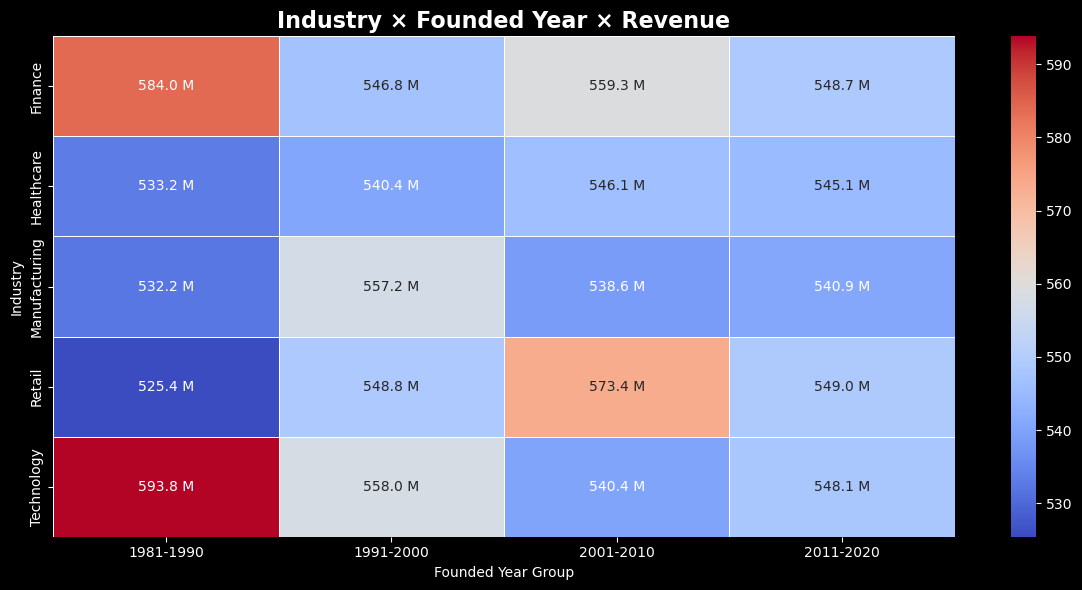

In [24]:
#Industry × Founded Year × Revenue


df['Founded_Year_Band'] = pd.cut(df['founded_year'],bins=[1980, 1990, 2000, 2010, 2020, 2030],
    labels=['1981-1990', '1991-2000', '2001-2010', '2011-2020', '2021+'])

pivot = df.pivot_table(values='annual_revenue_million',index='industry',columns='Founded_Year_Band',
                        aggfunc='mean')

plt.style.use('dark_background')
plt.figure(figsize=(12,6))

labels = pivot.round(1).astype(str) + " M"

sns.heatmap(pivot,annot=labels,fmt='',cmap='coolwarm',linewidths=0.5)

plt.title('Industry × Founded Year × Revenue',fontsize=16,fontweight='bold')

plt.xlabel('Founded Year Group')
plt.ylabel('Industry')

plt.tight_layout()
plt.show()

OBSERVATION

* The single highest average revenue in the entire dataset belongs to Technology companies founded between 1981–1990.
* Finance companies founded in the 1981–1990 bracket also show strong historical standing with an average revenue of 584.0 M.
* While older Retail companies started slower, Retail companies founded between 2001–2010 see a major spike, averaging 573.4 M. 
* All industries here sit tightly between 540 M and 549 M.
* Companies founded in the last 30 years tend to have highly stable, remarkably similar average revenues hovering around the 540 M–558 M mark.
* lowest average revenue on the chart belongs to Retail companies founded between 1981–1990 (525.4 M), closely followed by Manufacturing (532.2 M) and   Healthcare (533.2 M). 

In [25]:
df.dtypes

company_name                      object
industry                          object
country                           object
employee_count                     int64
annual_revenue_million           float64
profit_margin_percent            float64
founded_year                       int64
customer_count                     int64
market_rating                    float64
created_date              datetime64[ns]
region                            object
Founded_Year_Band               category
created_year                       int32
created_month                      int32
created_day                        int32
Revenue_Band                    category
Rating_Band                     category
Customer_Band                   category
dtype: object

BUILDING MACHINE LEARNING MODEL

* Problem Statement:Predict the Annual Revenue of a Company using company-related features.

#Importing required python libraries

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [28]:
# Load Dataset
df = pd.read_csv("INDUSTRY.csv")

df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


In [30]:
# Selecting Features
X = df.drop([
    'id',
    'company_name',
    'created_date',
    'annual_revenue_million'
], axis=1)

y = df['annual_revenue_million']

In [31]:
# Encoding Categorical Variables

le = LabelEncoder()

X['industry'] = le.fit_transform(X['industry'])
X['country'] = le.fit_transform(X['country'])
X['region'] = le.fit_transform(X['region'])

In [33]:
# Splitting Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
# Fitting training and testing data into model

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [38]:
# Making Predictions 

y_pred = model.predict(X_test)

print(y_pred[:10])  # Predicting only first 10 values.

[550.03247239 543.35476249 553.3409101  538.60075246 544.88299363
 533.31415034 548.49110965 553.50941524 548.07288591 549.62850101]


In [39]:
# Evaluating the Model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 248.36231971494476
MSE : 82489.67733359456
RMSE: 287.21016230905644
R2 Score: -0.0003537595781053504


In [48]:
# Comparing actual vs Predicted Output

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(5)

,Actual,Predicted
0,129.01,550.032472
1,759.85,543.354762
2,296.36,553.340910
3,913.22,538.600752
4,411.28,544.882994


In [49]:
# The predictions are all clustered around:540-550 million

In [52]:
# The comparison between actual and predicted revenue values shows that the predicted values are concentrated
# around the dataset mean (approximately 550 million).
# This indicates that the model could not learn meaningful patterns from the data
# and therefore produced predictions close to the average revenue value. This explains the low model performance and negative R² score.

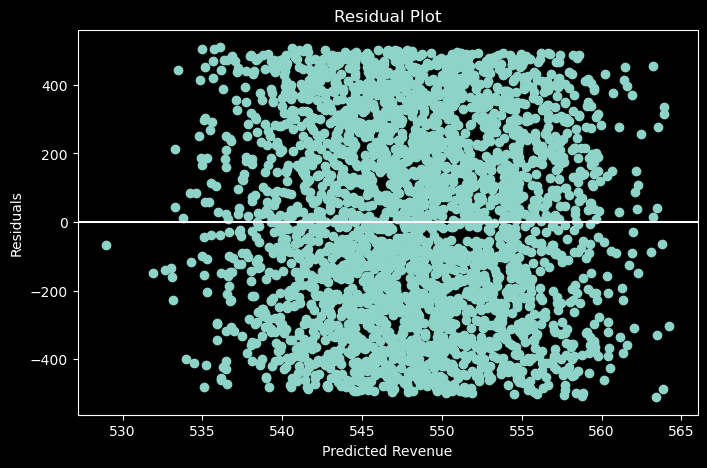

In [53]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [61]:
# Interpreting the plot

>The data points are randomly distributed around the horizontal zero line ($y = 0$).No clear patterns, waves, or curves seen.
which indicates that a linear model is a highly appropriate choice for this data.

#Final Conclusion

> A Linear Regression model was developed to predict annual company revenue using features such as industry, country, region, employee count, customer count, profit margin percentage, founded year, and market rating.

The model was trained using 80% of the data and tested on the remaining 20%. Model performance was evaluated using MAE, RMSE, and R² Score.

The model achieved an R² score of -0.00035, indicating that it was unable to explain the variation in annual revenue effectively. Correlation analysis performed during EDA showed that the predictor variables had very weak relationships with annual revenue, which explains the limited predictive performance.

The comparison of actual and predicted values showed that the model generated predictions close to the average revenue value, suggesting that meaningful predictive patterns were not present in the dataset.

Despite the low predictive accuracy, the project successfully demonstrated the complete machine learning workflow, including data preprocessing, feature encoding, model training, prediction, evaluation, and interpretation of results.


In [69]:
#--------------------------------------End of Project----------------------------------#